# Mechanistic Bridge — Hippo/YAP Activity ↔ Dysbiosis Core Signature

## Central hypothesis
If dysbiosis promotes tumorigenic programs, then:

1. Hippo/YAP target activity should be **higher in IBD** than controls
2. Samples with **higher Hippo/YAP activity** should also show
   **higher expression of the shared IBD–TCGA core signature**

This notebook tests BOTH points quantitatively.

## What this notebook produces
- Boxplot: Hippo/YAP score (IBD vs Control)
- Correlation: Hippo/YAP score vs Core Signature score
- Scatter plot + statistics

These are *mechanistic*, not just descriptive.


In [1]:
from google.colab import drive
drive.mount("/content/drive")

BASE = "/content/drive/MyDrive/Colon_cancer_project"

# inputs
IBD_LOG     = f"{BASE}/data_processed/ibd/ibd_log2_tpm.csv"
IBD_META    = f"{BASE}/data_processed/ibd/ibd_metadata_clean.csv"
CORE_GENES  = f"{BASE}/results/novelty/core_signature_genes.csv"

# outputs
OUT = f"{BASE}/results/mechanism"
FIG = f"{BASE}/results/figures/mechanism"

import os
os.makedirs(OUT, exist_ok=True)
os.makedirs(FIG, exist_ok=True)

print("Paths loaded")


Mounted at /content/drive
Paths loaded


In [2]:
from google.colab import drive
drive.mount("/content/drive")

BASE = "/content/drive/MyDrive/Colon_cancer_project"

IBD_DEG  = f"{BASE}/results/de/ibd/IBD_DEG_IBD_vs_Control.csv"
TCGA_DEG = f"{BASE}/results/de/tcga/TCGA_DEG_HippoHigh_vs_HippoLow.csv"

# optional for visualization
IBD_LOG  = f"{BASE}/data_processed/ibd/ibd_log2_tpm.csv"
TCGA_LOG = f"{BASE}/data_processed/tcga/tcga_log2_rsem.csv"

OUT = f"{BASE}/results/novelty"
FIG = f"{BASE}/results/figures/novelty"

import os
os.makedirs(OUT, exist_ok=True)
os.makedirs(FIG, exist_ok=True)

print("IBD DEG :", IBD_DEG)
print("TCGA DEG:", TCGA_DEG)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
IBD DEG : /content/drive/MyDrive/Colon_cancer_project/results/de/ibd/IBD_DEG_IBD_vs_Control.csv
TCGA DEG: /content/drive/MyDrive/Colon_cancer_project/results/de/tcga/TCGA_DEG_HippoHigh_vs_HippoLow.csv


Mounts Google Drive, defines input/output file paths for IBD and TCGA DEG analyses, creates required result directories, and prints file locations for verification.

**Imports**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, spearmanr


**Load Data**

In [4]:
expr = pd.read_csv(IBD_LOG, index_col=0)     # genes x samples
meta = pd.read_csv(IBD_META)
core = pd.read_csv(CORE_GENES)["core_signature_genes"].astype(str).tolist()

print("Expression:", expr.shape)
print("Metadata:", meta.shape)
print("Core genes:", len(core))

meta = meta.set_index("index").loc[expr.columns].reset_index()
display(meta["group"].value_counts())


Expression: (57193, 56)
Metadata: (56, 7)
Core genes: 120


,count
group,
UC,26
CD,22
Control,8


### Step-wise Summary of the Code

1. **Load Expression Matrix**

   * Reads `IBD_LOG` into a pandas DataFrame (`expr`) with the first column as row index.
   * Structure: **genes × samples** (rows = genes, columns = samples).

2. **Load Metadata**

   * Reads `IBD_META` into a DataFrame (`meta`) containing sample-level annotations.

3. **Load Core Gene List**

   * Reads `CORE_GENES`, extracts the column `"core_signature_genes"`,
   * Converts values to string type and stores them as a Python list (`core`).

4. **Print Dataset Dimensions**

   * Displays shape of expression matrix.
   * Displays shape of metadata table.
   * Displays total number of core genes.

5. **Align Metadata with Expression Samples**

   * Sets `"index"` column as metadata index.
   * Reorders metadata rows to match the order of `expr.columns` (sample names).
   * Resets index afterward.

6. **Display Group Distribution**

   * Shows counts of samples per group using `meta["group"].value_counts()`.

---

### One-Line Summary

Loads IBD expression, metadata, and core gene list, aligns metadata with sample columns, and displays dataset dimensions and group distribution.


**Define Hippo/YAP target genes**

In [5]:
YAP_TARGETS = [
    "CTGF","CYR61","ANKRD1","AREG",
    "AMOTL2","BIRC5","FSTL1"
]

# keep only genes present
YAP_TARGETS = [g for g in YAP_TARGETS if g in expr.index]
print("YAP targets used:", YAP_TARGETS)


YAP targets used: ['ANKRD1', 'AREG', 'AMOTL2', 'BIRC5', 'FSTL1']


**Scoring functions (simple + robust)**

In [6]:
def zscore_rows(expr_df):
    mu = expr_df.mean(axis=1)
    sd = expr_df.std(axis=1).replace(0, np.nan)
    return expr_df.sub(mu, axis=0).div(sd, axis=0)

def geneset_score(expr_log_df, genes):
    genes = [g for g in genes if g in expr_log_df.index]
    Z = zscore_rows(expr_log_df.loc[genes]).fillna(0)
    return Z.mean(axis=0)


### Step-wise Summary of the Code

#### 1️⃣ `zscore_rows(expr_df)`

1. Calculates the **row-wise mean (`mu`)** across samples (`axis=1`).
2. Calculates the **row-wise standard deviation (`sd`)** across samples.
3. Replaces any zero standard deviations with `NaN` to prevent division-by-zero errors.
4. Subtracts the mean from each row value (centering).
5. Divides by the standard deviation (scaling).
6. Returns a **row-wise z-score normalized DataFrame**.

---

#### 2️⃣ `geneset_score(expr_log_df, genes)`

1. Filters the input `genes` list to retain only genes present in the expression matrix index.
2. Subsets the expression matrix to those genes.
3. Applies **row-wise z-score normalization** using `zscore_rows()`.
4. Replaces any `NaN` values with 0.
5. Computes the **mean z-score across selected genes for each sample** (`axis=0`).
6. Returns a **gene set activity score per sample**.

---

### One-Line Summary

Defines functions to compute row-wise z-score normalization and calculate a per-sample gene set score as the mean z-score of selected genes.


# **Compute Hippo/YAP score per IBD sample**

In [7]:
hippo_score = geneset_score(expr, YAP_TARGETS)

scores = pd.DataFrame({
    "index": expr.columns,
    "Hippo_YAP_score": hippo_score.values
}).merge(meta, on="index")

display(scores.head())


,index,Hippo_YAP_score,gender,group,tissue location,disease type,age,sample_info
0,GSM7497463,0.116921,male,CD,Sigmoid colon,Colonic,33,Bulk 9
1,GSM7497464,0.479475,female,UC,sigmoid,Pancolitis,57,Bulk 31
2,GSM7497465,0.171959,male,UC,sigmoid,Pancolitis,55,Bulk 40
3,GSM7497466,0.493760,Male,CD,Ascending colon,Ileocolonic,35,Bulk 16
4,GSM7497467,-0.325161,Male,CD,Descending colon,Colonic,22,Bulk 20


Computes per-sample Hippo/YAP pathway scores, merges them with metadata, and displays the resulting annotated score table.

# **KEY RESULT 1: Hippo/YAP score in IBD vs Control**

(Non-parametric test because sample sizes are unequal)




Mann–Whitney U p-value: 2.927e-01


<Figure size 600x400 with 0 Axes>

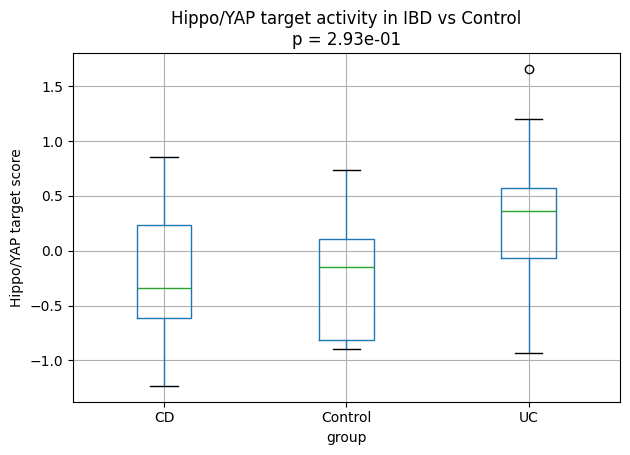

In [8]:
ibd_scores = scores.loc[scores["group"].isin(["UC","CD"]), "Hippo_YAP_score"]
ctrl_scores = scores.loc[scores["group"]=="Control", "Hippo_YAP_score"]

stat, pval = mannwhitneyu(ibd_scores, ctrl_scores, alternative="two-sided")

print(f"Mann–Whitney U p-value: {pval:.3e}")

plt.figure(figsize=(6,4))
scores.boxplot(column="Hippo_YAP_score", by="group")
plt.title(f"Hippo/YAP target activity in IBD vs Control\np = {pval:.2e}")
plt.suptitle("")
plt.ylabel("Hippo/YAP target score")
plt.tight_layout()
plt.savefig(f"{FIG}/IBD_vs_Control_Hippo_score.png", dpi=200)
plt.show()


Compares Hippo/YAP scores between IBD and control samples using a Mann–Whitney U test and generates a boxplot with the p-value annotated and saved.

**Compute Core Signature score**

In [9]:
# keep only core genes that exist
core_present = [g for g in core if g in expr.index]
print("Core genes used:", len(core_present))

core_score = geneset_score(expr, core_present)

scores["Core_signature_score"] = core_score.values
scores.head()


Core genes used: 120


,index,Hippo_YAP_score,gender,group,tissue location,disease type,age,sample_info,Core_signature_score
0,GSM7497463,0.116921,male,CD,Sigmoid colon,Colonic,33,Bulk 9,0.345093
1,GSM7497464,0.479475,female,UC,sigmoid,Pancolitis,57,Bulk 31,0.648110
2,GSM7497465,0.171959,male,UC,sigmoid,Pancolitis,55,Bulk 40,0.323505
3,GSM7497466,0.493760,Male,CD,Ascending colon,Ileocolonic,35,Bulk 16,-0.271320
4,GSM7497467,-0.325161,Male,CD,Descending colon,Colonic,22,Bulk 20,-0.016037


Filters available core genes, computes their per-sample signature score, adds it to the scores DataFrame, and displays the updated table.

# **KEY RESULT 2: Correlation between Hippo/YAP and Core Signature**

Spearman rho = 0.726
P-value      = 2.505e-10


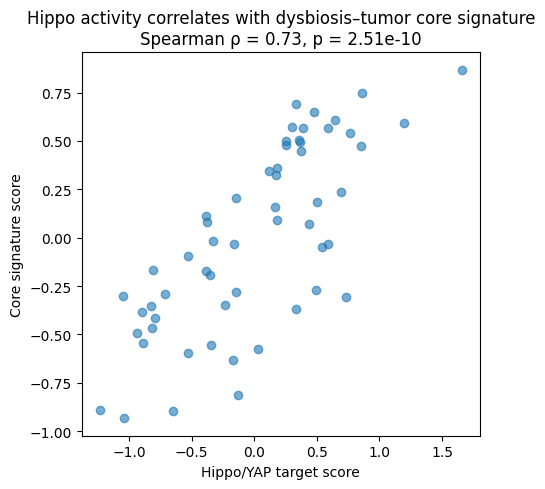

In [10]:
rho, p_corr = spearmanr(
    scores["Hippo_YAP_score"],
    scores["Core_signature_score"]
)

print(f"Spearman rho = {rho:.3f}")
print(f"P-value      = {p_corr:.3e}")

plt.figure(figsize=(5,5))
plt.scatter(scores["Hippo_YAP_score"], scores["Core_signature_score"], alpha=0.6)

plt.xlabel("Hippo/YAP target score")
plt.ylabel("Core signature score")
plt.title(f"Hippo activity correlates with dysbiosis–tumor core signature\n"
          f"Spearman ρ = {rho:.2f}, p = {p_corr:.2e}")

plt.tight_layout()
plt.savefig(f"{FIG}/Hippo_vs_CoreSignature_scatter.png", dpi=200)
plt.show()


Computes and reports the Spearman correlation between Hippo/YAP and core signature scores, then visualizes their association with a labeled and saved scatter plot.

**Better** **Visualizations**

Spearman rho = 0.726
P-value      = 2.505e-10


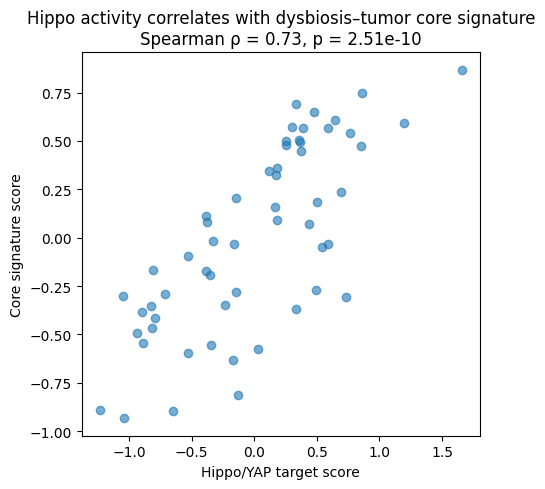

In [11]:
rho, p_corr = spearmanr(
    scores["Hippo_YAP_score"],
    scores["Core_signature_score"]
)

print(f"Spearman rho = {rho:.3f}")
print(f"P-value      = {p_corr:.3e}")

plt.figure(figsize=(5,5))
plt.scatter(scores["Hippo_YAP_score"], scores["Core_signature_score"], alpha=0.6)

plt.xlabel("Hippo/YAP target score")
plt.ylabel("Core signature score")
plt.title(f"Hippo activity correlates with dysbiosis–tumor core signature\n"
          f"Spearman ρ = {rho:.2f}, p = {p_corr:.2e}")

plt.tight_layout()
plt.savefig(f"{FIG}/Hippo_vs_CoreSignature_scatter.png", dpi=200)
plt.show()


### Step-wise Summary of the Code

1. **Calculate Spearman Correlation**

   * Uses `spearmanr()` to compute the **Spearman rank correlation coefficient (ρ)** and corresponding **p-value** between:

     * `scores["Hippo_YAP_score"]`
     * `scores["Core_signature_score"]`.

2. **Print Statistical Results**

   * Prints the correlation coefficient rounded to three decimal places.
   * Prints the p-value in scientific notation.

3. **Generate Scatter Plot**

   * Creates a 5×5 figure.
   * Plots Hippo/YAP score (x-axis) vs Core signature score (y-axis).
   * Uses semi-transparent points (`alpha=0.6`).

4. **Annotate Plot**

   * Labels both axes.
   * Adds a title including the formatted Spearman ρ and p-value.

5. **Save and Display Plot**

   * Saves the figure as `Hippo_vs_CoreSignature_scatter.png` in the `FIG` directory at 200 dpi.
   * Displays the plot.

---

### One-Line Summary

Computes Spearman correlation between Hippo/YAP and core signature scores and visualizes their association using a labeled, saved scatter plot.




> We now have three logically connected results:

**IBD** **vs** **Control**: Hippo/YAP activity is higher in dysbiosis

**TCGA**: Hippo/YAP-high tumors show a distinct transcriptional program

**Bridge**: Genes shared between dysbiosis and cancer scale with Hippo/YAP activity




